##### **Unconditional Marginal PD**

Probability of default that is unconditional on prior 
period default and prepayment.


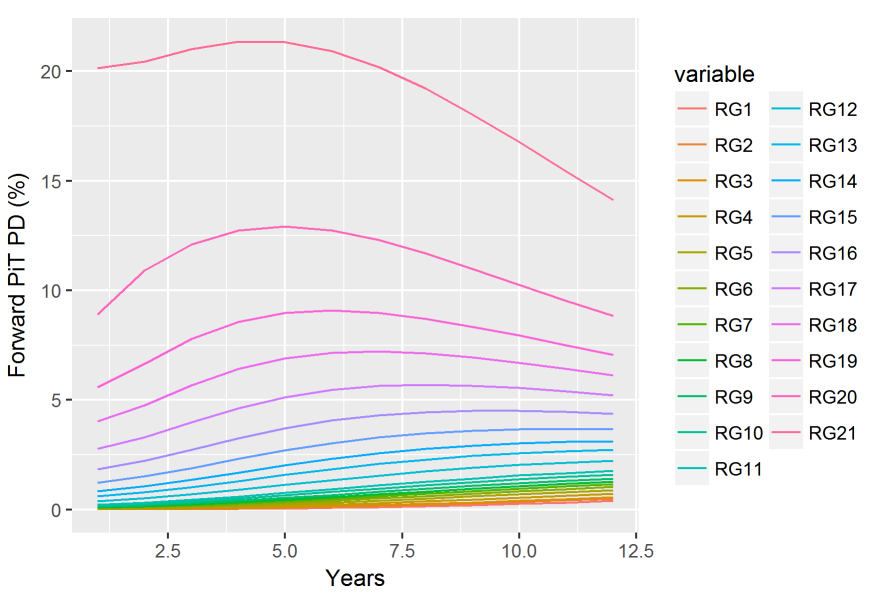

##### **Survival Rate**

A survival rate is required to convert an unconditional PD into a 
conditional PD and is calculated as follows:

$SR_t = SR_{t-1}(1-PD_t^C-PR_t^C)$ where
- $SR_t$ is the survival rate in period t
- $PD_t^C$ is the conditional probability of default in period t
- $PR_t^C$ is the conditional probability of full redemption in period t

##### **Conditional Marginal PDs**

Takes into account survival rate and prior defaults. 

$PD_t^U=PD_t^C \times SR_{t-1}$

For instance:
- A 1-month PD is the probability of default over the first month.
- A 12-month PD is the cumulative probability of default over 12 months.
- A lifetime PD is the probability of default over the remaining life of the asset.

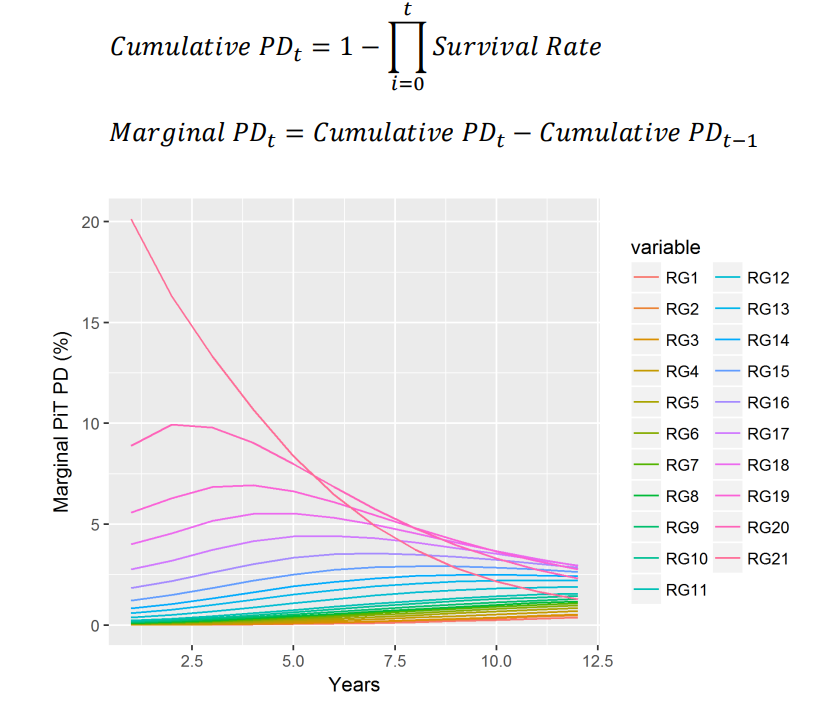

##### **Lifetime PDs**

In facilitating feature engineering and certain comparisons, we require estimates of a loan’s intrinsic default risk over its lifetime. Accordingly, an elementary but typical model is built for predicting this probability of defaulting (PD) over a 12-month period, as applied at any point during loan life. Note that §5.5.9 in IFRS 9 from the IASB (2014)
technically requires the use of a lifetime PD-measure when monitoring default risk over loan life for SICR-purposes, which suggests the use of more sophisticated survival models. 

However, and as allayed in §B5.5.13, a 12-month PD-measure can reasonably approximate its lifetime counterpart when the former captures the most salient of time-dependent default patterns over loan life.

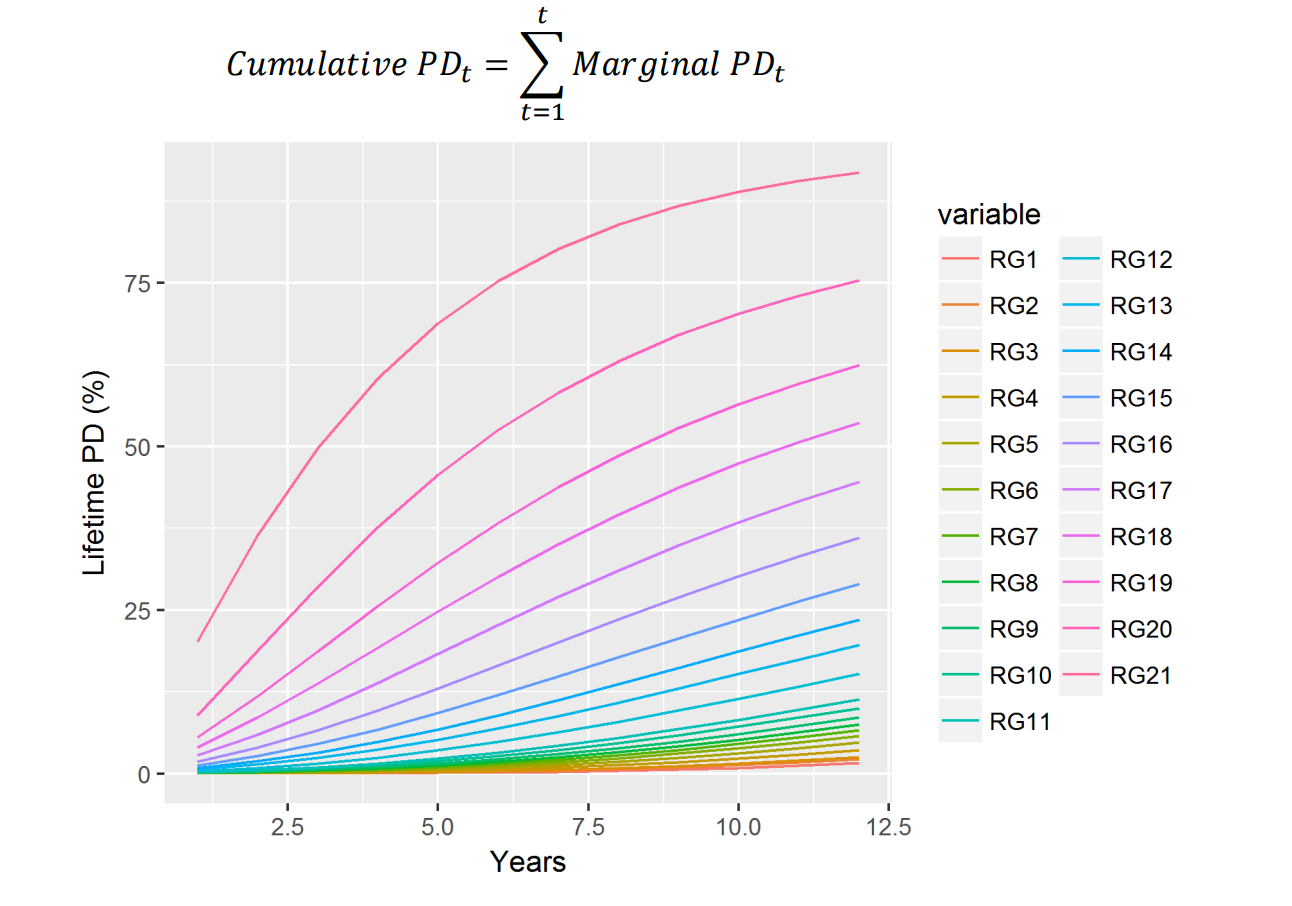

## **SICR** 🟢

Under IFRS 9: Financial Instruments, the concept of a Significant Increase in Credit Risk (SICR) is a critical component of the impairment model. It requires financial institutions to assess whether the credit risk of a financial asset has significantly increased since its initial recognition. If there is a SICR, the asset transitions from Stage 1 to Stage 2 in the Expected Credit Loss (ECL) framework. This increases the ECL since we are now using a lifetime PD and EAD. 

The IFRS 9 standard does not prescribe a single method for determining a SICR but provides principles and guidelines. IFRS 9 allows institutions to design their SICR framework, which introduces variability across entities. 


Factors to consider the occurence of SICR includes, but is not limited to:
- Quantitative indicators: PD comparison where a residual lifetime PD should used. It implies that the same remaining period is considered for PD at origination and reporting date. As a proxy, a 12m PD can be used if changes in a 12m PD are a reasonable approximation to changes in a lifetime PD.
- Qualitative indicators: IFRS 9 provides some examples such as credit spread, CDS price etc. These factors should considered separately as they are not included in the quantitative assessment.


### **PD Comparison Approach** 🟢

Let this $t$-month PD be denoted by $p_{t}(x_i,t')$ given risk information $x$ observed at time $t'$ for a specific loan account. A SICR-event can then be defined by comparing $p_1(x,t'_r)$ with $p_1(x,t'_i)$ between reporting time $t'_r$ and initial recognition time $t'_i$ , which reflects §5.5.9 in IFRS 9. An accounted is SICR if there is a significant increase in the current FLI-adjsuted PD compared to the initial application PD (regardless of how it changed in between). 

Should this change in risk estimates, or the magnitude $m(x,t'_r)$, exceed some arbitrarily chosen threshold $u$, then a SICR-event is said to have occurred. Note that $m(x,t'_r)$ can refer either to the difference $p_1(x,t'_r) -p_1(x,t'_i)$, or to the ratio $p_1(x,t'_r)/p_1(x,t'_i)$; though both definitions signify the change in lifetime PD. $m(x,t'_r) > u$, then the loan is migrated to Stage 2, otherwise it remains in Stage 1. Given any 𝑢-value, we subsequently formulate this approach into
the binary-valued decision model $H(𝑚, 𝑢) ∈ {0, 1}$

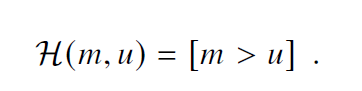

The converse is presumably true as well: a Stage 2 loan is migrated back to Stage 1 once its risk has improved, i.e., if $m(x,t_r'')\leq u$ at some future time $t_r''> t_r'$ . Doing so would be cost-efficient, particularly since overzealous Stage 2 classification can become prohibitively costly, even if risk-prudent.


This approach immediately highlights at least two challenges in establishing whether credit quality has deteriorated significantly. 
1. Selecting an appropriate threshold for the magnitude is non-trivial and highly subjective, which is exacerbated by IFRS 9 being principled instead of overly prescriptive. Neither IFRS 9 nor most regulators offer any firm guidance on the choice of $u$. While the European Banking Authority defines $u = 200\%$, it provides no explanation for this seemingly arbitrary value. In fact, the PRA observed multiple threshold-values that were in use across UK banks and even across different portfolios; all of which attests to further arbitrariness.
2. Secondly, any reliance on the point estimate PD tacitly requires a certain degree of accuracy. Examples: inappropriate
modelling technique, failing to capture the time-dynamic nature of lifetime PD, selecting good predictive variables, data quality, paucity of data for low default portofolios.

The UK-regulator is unsurprised by these differences in SICR-classification, presumably due to the underlying differences across banks in their risk appetites, strategies, and portfolio compositions. 

https://www.pwc.com/gx/en/audit-services/ifrs/publications/ifrs-9/ifrs-9-impairment-significant-increase-in-credit-risk.pdf


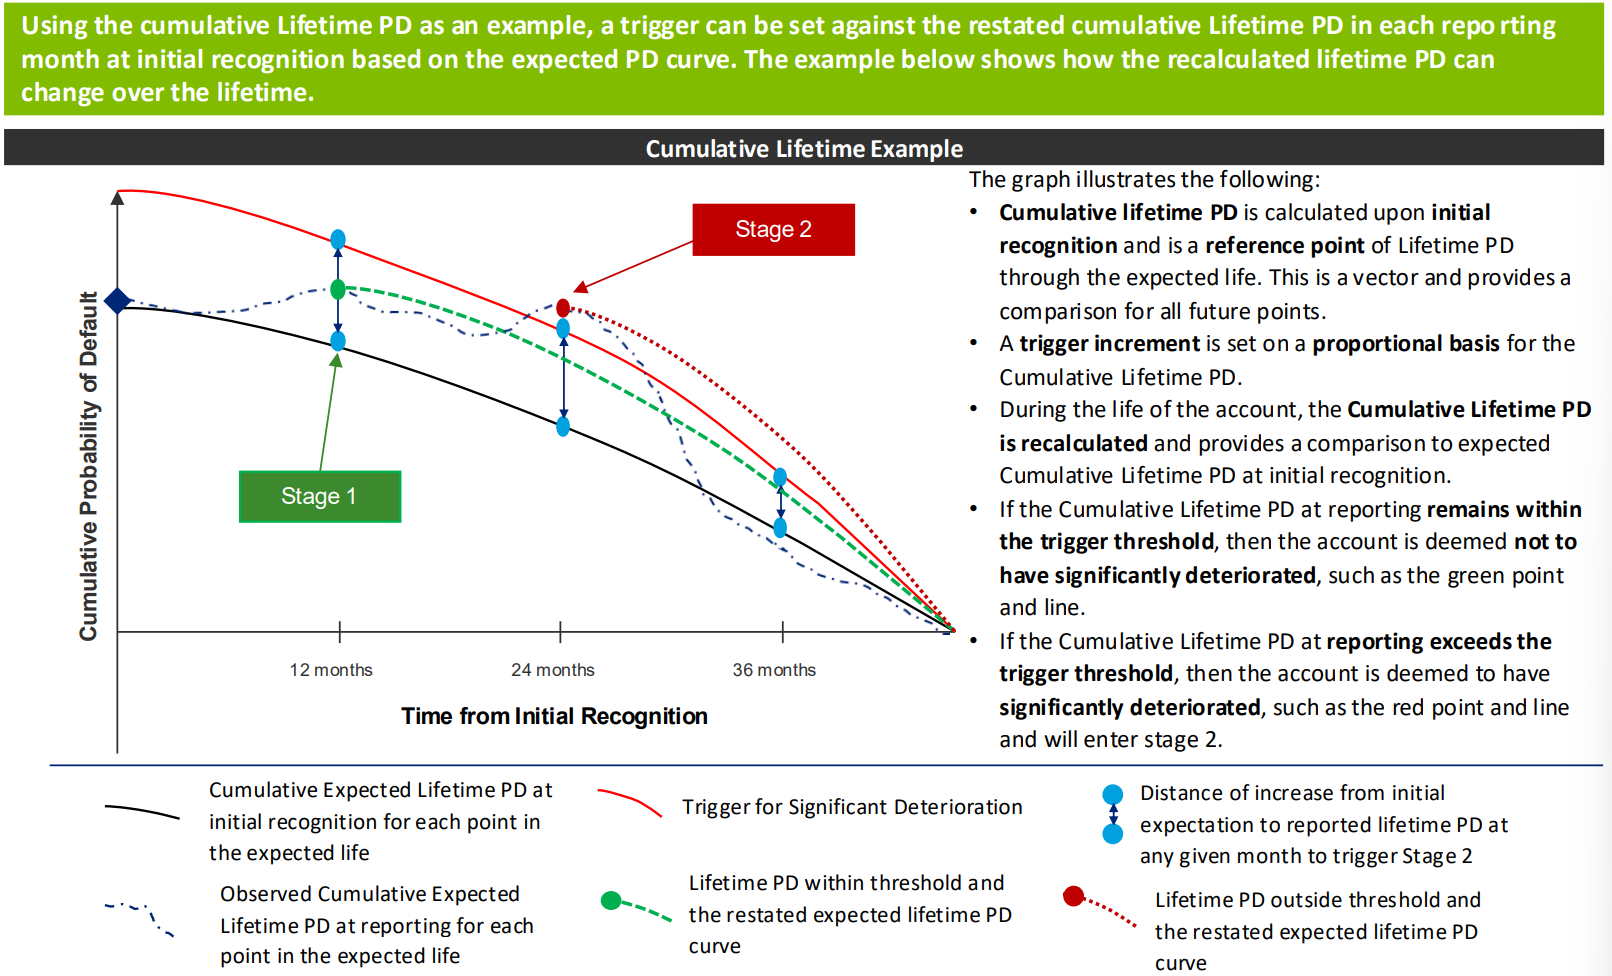

#### **Threshold Options**

The requirement for the use of significant deterioration requires a methodology to both define what is “significant” and identify a 
trigger process to apply the deterioration. The application and identification of these triggers has not yet been established in the 
industry. However, there are a number of ways being considered.

There are a number of approaches that can be used to apply the thresholds and triggers for an increase in credit risk using a Lifetime 
PD. Based on a simple total lifetime PD by grade, the following are examples identifying the PD Trigger:
- Absolute
- Fixed
- Proportional
- Combination

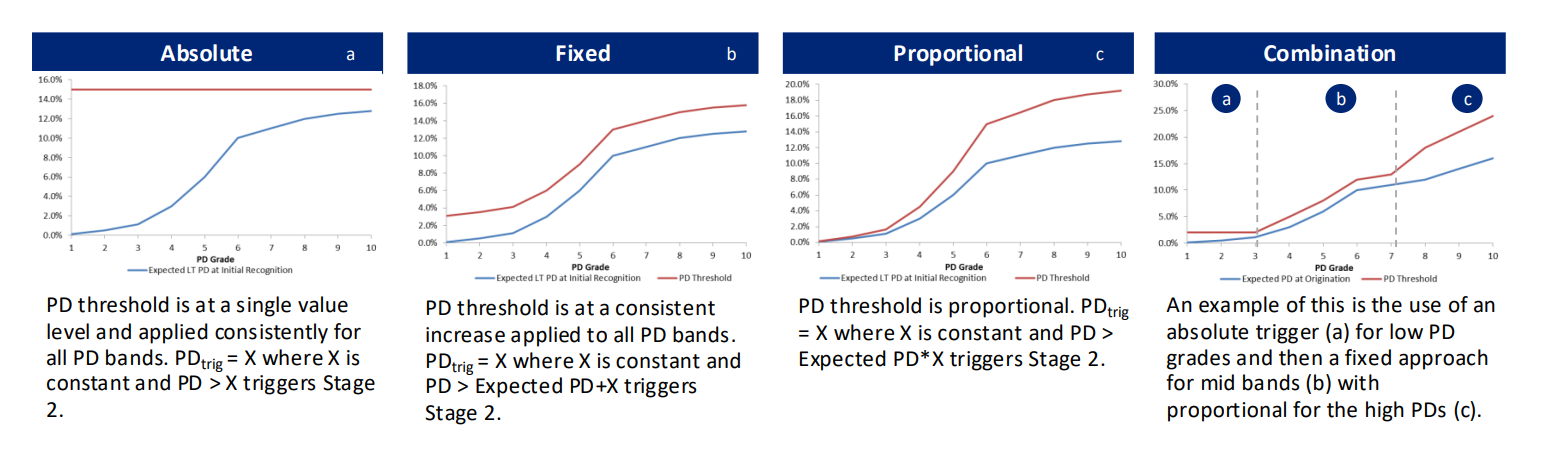

#### **Boundary Calibration**

The selection of boundary between Stage 1 and Stage 2 is a special case of a scientific problem that has existed since at least the development of Radar in the 1930s. The problem of “is it a bird, or is it a bomber” is also encountered in many medical and scientific applications. Optimal separation of birds and bombers requires calibration of a threshold which minimises the Mean Square Error.

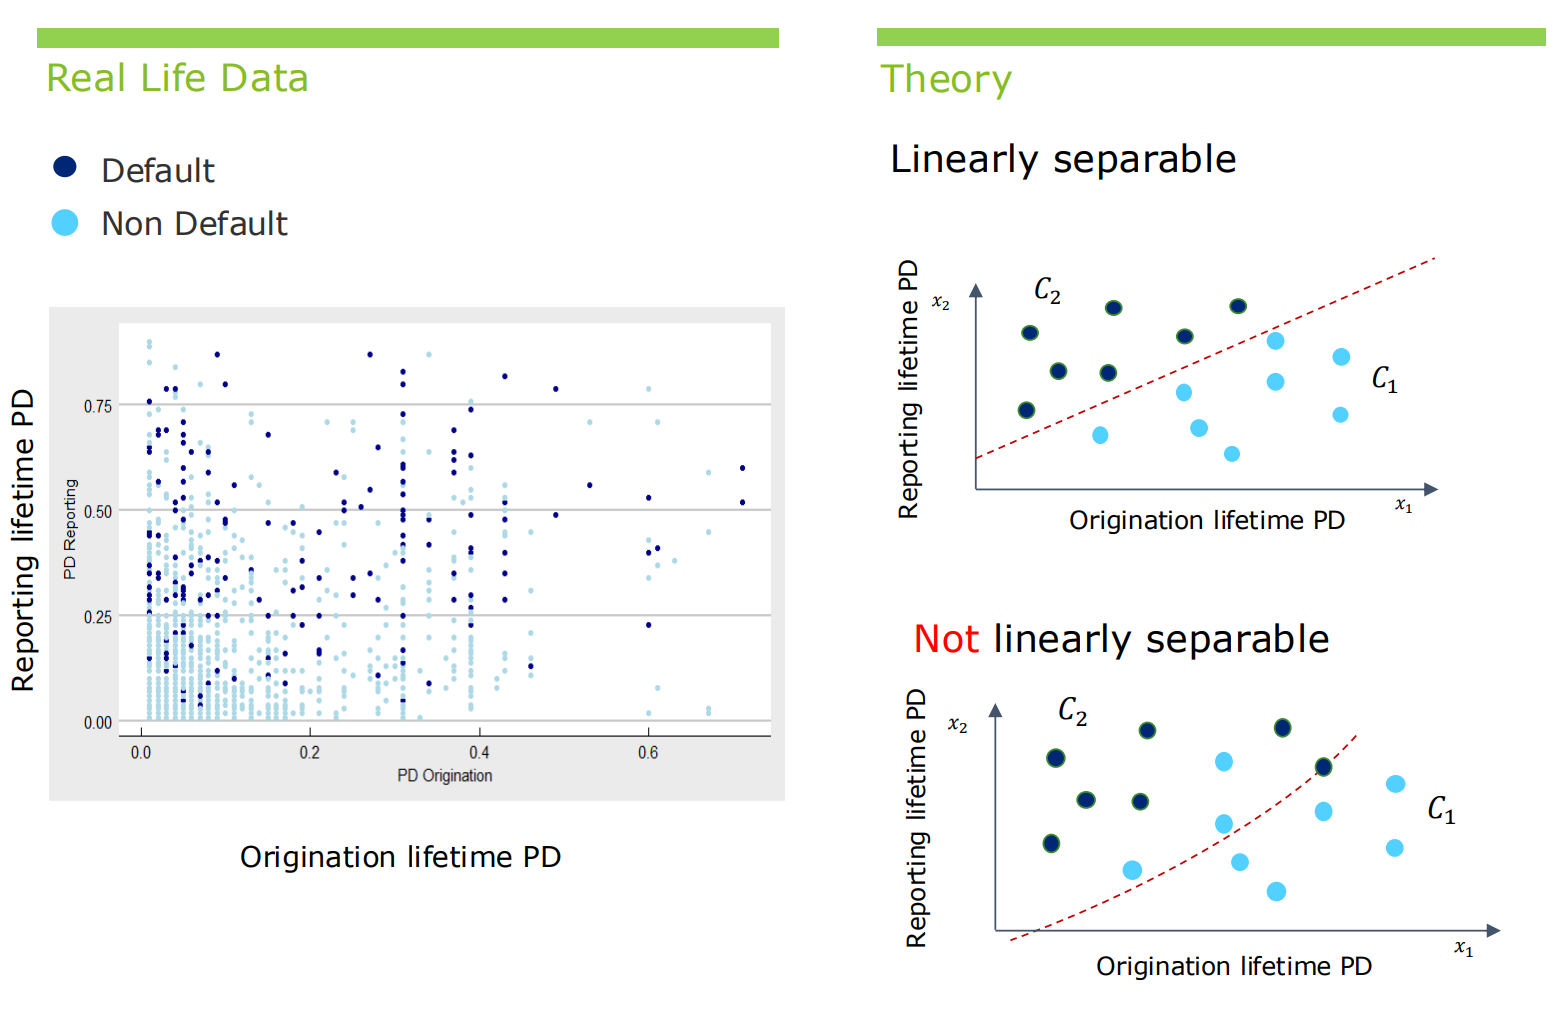

#### **Forward Roll Rates** 🟢

Some banks select $u$ such that the SICR-flagged population constitutes a pre-defined % of the portfolio, where the percentage is based on the observed transition rate (**roll rate**) of becoming delinquent, i.e., reaching 30 days past due (Stage 1 to Stage 2). Roll rates offer a dynamic and quantitative way to model credit risk and inform SICR criteria. Roll rates represent the probability of a loan transitioning from one delinquency bucket to another over a specified time horizon.  

You can plot these roll rates historically to determine an average roll rate and use that to inform what % of your portofolio should be SICRed. 


You determine the transition probabilities between delinquency buckets over the last 12 months lets say. If 10 out of 100 loans in the "current" bucket transition to the "1–30 days past due" bucket, the roll rate is 10%. At the reporting date, we then will move 10% of the accounts. But the question then becomes which accounts do we move? This is then up to the individual banks to look at other variables such as:
- Change in orgination vs current PDs
- Number of other loans
- Performance on other loans

A good example is if you have a home loan and a credit card. If you were to miss a payment it would be on your credit card since missing payments on your home could lead to repossesion. Hence, you would be SICRed on your home loan ECL should you miss payments on your credit card.

While certainly simple, this method suffers from at least three major drawbacks.

1. The precise way in which the roll rate is calculated can adversely affect the chosen $u$-value, if done incorrectly. Some notable risk factors include both the length and recency of the underlying sampling window, which may be inappropriately short or exclude known periods of macroeconomic distress. 
2. Targeting any % presumes that the delinquent proportion of a portfolio will itself remain largely static in future. This rather crude assumption surely cripples the risk-sensitivity of SICR-classification, especially so during times of macroeconomic upheaval, precisely when SICR-classification should have been dynamic. 
3. Stakeholders commonly disagree when adjusting this %-value across different macroeconomic scenarios, which
renders the eventual $u$ value as highly subjective and possibly divorced from reality.






### **SICR Modelling** 🟢

The basis of ‘SICR-modelling’ is then finding a statistical relationship between future SICR-events and a broad set of present-day inputs that predict those SICR-events. Such a binary classification task can render SICR-predictions more accurately, which includes the change in risk since initial recognition; i.e., the magnitude $m(x, t_r)$.

In fact, IFRS 9 already requires the use of "all reasonable and supportable information" to identify a SICR-event (cf. §5.5.4, §5.5.9, §5.5.11, §5.5.17), which further supports statistical modelling.

It is not strictly necessary to compare explicit PD-estimates at two points, provided that the evolution of default risk over time is incorporated in some other way. In principle, and when viewed retrospectively, a SICR-event should reasonably preempt a default event such that the **timings of both events do not coincide**, lest we contravene §B5.5.21. This principle suggests using loan delinquency (and its pre-default evolution) directly in defining a SICR-event, at least retrospectively. 

#### **SICR Indicators**

In defining a SICR-event, one can compare the deliquency measure $𝑔_0(𝑡)$ at time 𝑡 against a specifiable threshold 𝑑. In fact, delinquency can be tested over multiple consecutive months, thereby ensuring that a ‘true’ SICR-event is eventually identified at 𝑡. Such a preliminary SICR-event is said to have occurred at time 𝑡 if $𝑔_0(𝑣) ≥ 𝑑$ holds true across a fixed time span $𝑣 ∈ [𝑡 − (𝑠 − 1), 𝑡]$. The specifiable
parameter $𝑠 ≥ 1$ is the number of consecutive months for which delinquency is tested; put differently, 𝑠 is the **stickiness** of the aforementioned delinquency test. These ideas are formalised within the Boolean-valued decision function $G(𝑑, 𝑠, 𝑡)$ that yields a binary-valued SICR-status in defining a SICR-event at an end-point 𝑡, expressed as:

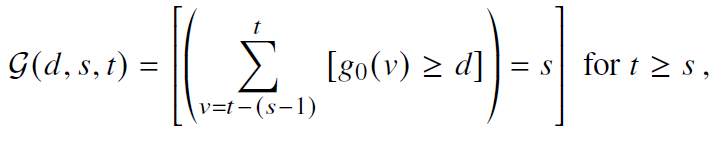

where [𝑎] are Iverson brackets that outputs 1 if the enclosed statement 𝑎 is true and 0 otherwise. The 𝑠-parameter simply smooths away rapid 0/1-fluctuations in the SICR-status over time, thereby becoming ‘sticker’ as 𝑠 increases.

The loan’s resulting binary-valued SICR-statuses, i.e., its $G(𝑑, 𝑠, 𝑡)$-values, can now be used within a typical cross-sectional modelling setup for predicting future SICR-events, or SICR-outcomes.

In preparing the modelling dataset, we observe all predictive information of loan $𝑖$ at a particular time 𝑡. Then, the loan’s future SICR-status at time $𝑡 + 𝑘$ is merged to the observations at 𝑡, thereby taking a snapshot between two points in time, or a cross-section. However, the chosen value for this third parameter $𝑘 ≥ 0$ (or outcome period) can significantly affect modelling results.

More formally, a process $Z_𝑡 (𝑑, 𝑠, 𝑘) = G(d,s,t+k)$ prepares a given loan’s monthly performance history by evaluating G at ‘future’ time $𝑡 + 𝑘$, though assigns the result to time 𝑡

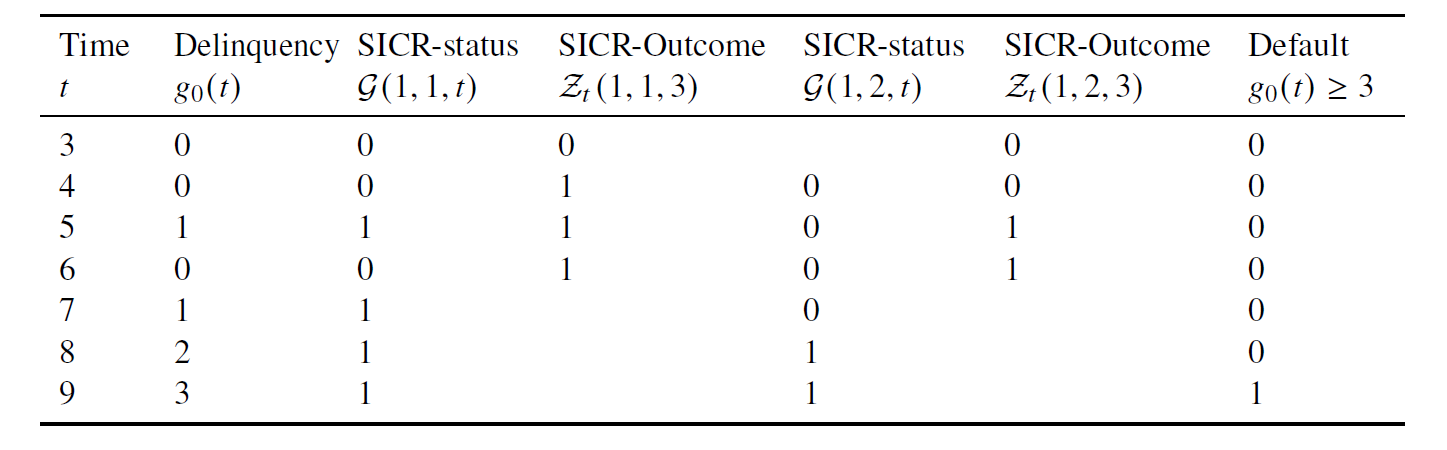

Various SICR-definitions are generated using the $Z_𝑡(𝑑, 𝑠, 𝑘)$-process simply by systematically varying its parameters $(𝑑, 𝑠, 𝑘)$.

The parameter space includes: 1) the threshold 𝑑 ∈ {1, 2} of $𝑔_0$-measured delinquency beyond which SICR is triggered; 2) the level of stickiness 𝑠 ∈ {1, 2, 3} within the delinquency test; and 3) the choice of outcome period 𝑘 ∈ {3, 6, 9, 12} when modelling SICR-outcomes. While the parameter spaces of 𝑑 and 𝑠 are appreciatively small, the same luxury does not hold for the outcome period 𝑘, which can indeed assume many values.

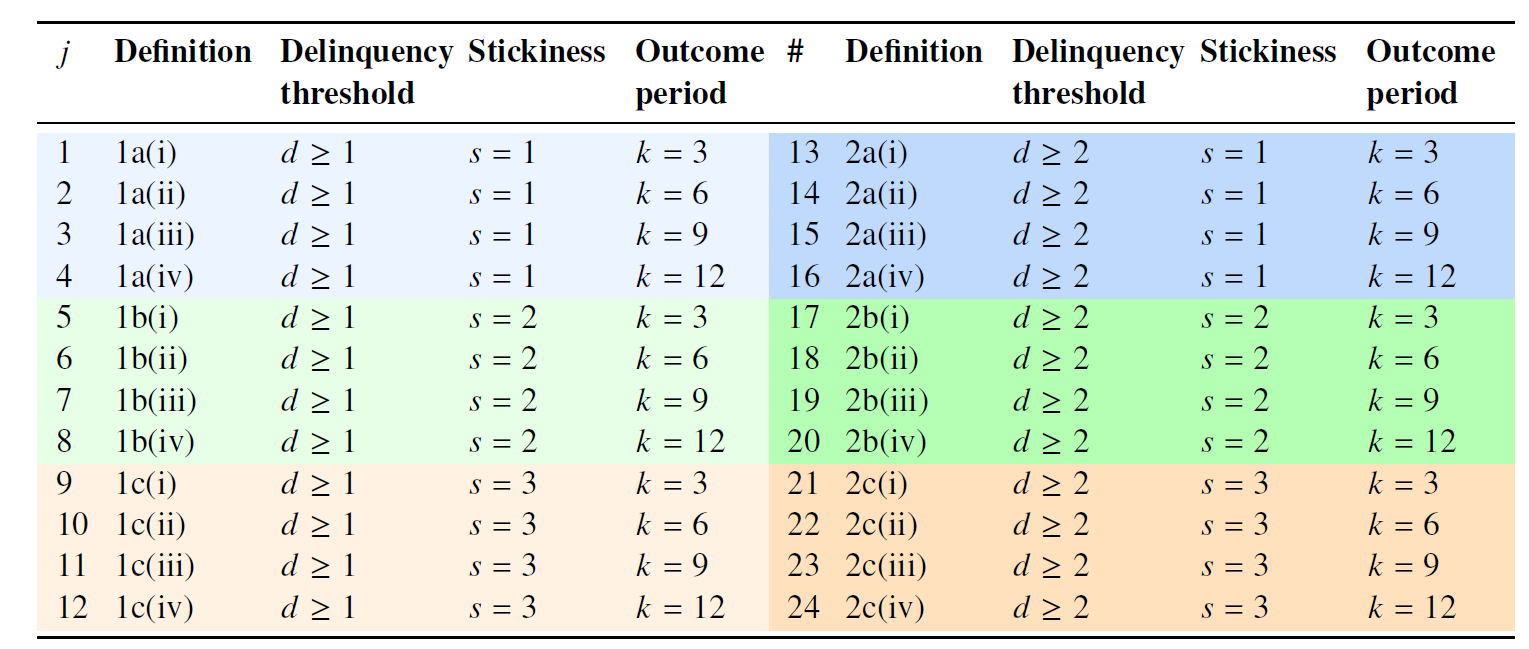

Each entry in the table can serve as a particular target definition in building a corresponding SICR-model using some technique.

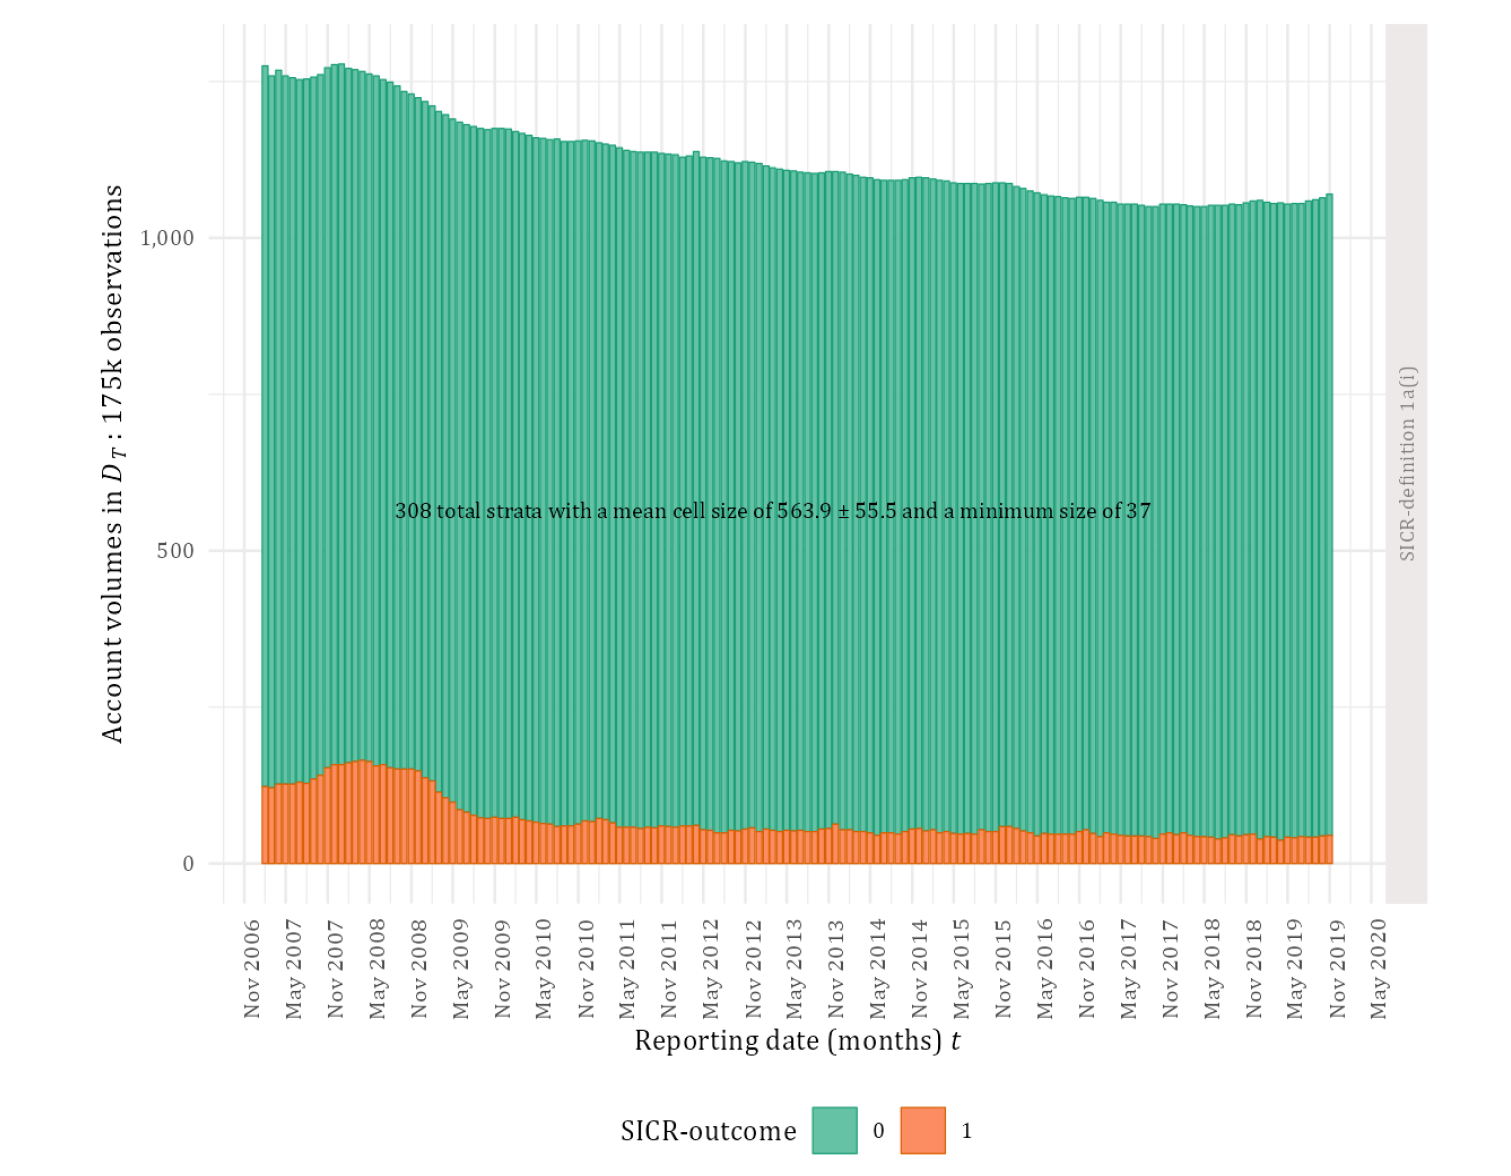

#### **Binary Logistic Regression**

Our chosen chosen modelling technique is binary logistic regression, given its ubiquity in credit risk modelling. Each resulting logit-model will therefore yield a probability score for a particular account at each point during its lifetime. These 𝑘-month forward SICR-predictions reasonably approximate their true lifetime counterpart, which can admittedly only be rendered by using more dynamic/complex modelling techniques, e.g., survival analysis.

In predicting the SICR-outcomes $𝑦_{𝑖𝑡}$ for each outcome period, consider the raw dataset D as a realised vector of input variables. These variables are thematically grouped as follows:
1. account-level information $𝒙_𝑖$ for loan 𝑖, e.g., repayment type (debit order, cash);
2. macroeconomic information $𝒙_𝑡$ at time 𝑡, e.g., the prevailing inflation rate;
3. time-dependent behavioural information $𝒙′_{𝑖𝑡}$ , e.g., the time spent in a performing spell, or the PD-ratio that signifies the change in default risk since initial recognition.

Here we are trying to model the **conditional SICR probability**.

The probabilistic SICR-predictions from logit-models will need to be dichotomised towards rendering impairment staging decisions under IFRS 9, i.e., Stage 1 or 2, which are respectively called a ‘negative’ or
‘positive’ event. An appropriate cut-off c ∈ [0, 1] is therefore required for dichotomising each probability score 𝑝 ∈ [0, 1] from each SICR-model 𝑗. 

Moreover, SICR-outcomes are relatively rare and the consequences of misclassifying positives vs. negatives are intuitively unequal. Under IFRS 9, false negatives 𝐹− should be costlier than false positives 𝐹+ in that the former implies the bank has failed to increase its loss provision for those accounts with increasing credit risk, i.e., those accounts with an actual future SICR-outcome. Misclassification costs are accordingly assigned as $𝑐_{𝐹-}$ = 6 for false negatives and $𝑐_{𝐹+}$ = 1 for false positives, which implies an intuitively high cost ratio of 𝑎 = 6/1 across all SICR-models. 

These costs are deduced using expert judgement and experimentation, though can certainly be refined in future work. Given this 𝑎-value, each 𝑐-value is then found using the Generalised Youden Index.

Finally, each SICR-model is dichotomised into the discrete classifier ℎ that yields the class prediction $ℎ(𝒙_𝑖) = 1$ if $𝑝(𝒙_𝑖) > 𝑐$ and $ℎ(𝒙_𝑖) = 0$ otherwise.

#### **Feature Selection**

Selecting viable input variables within each SICR-model is mainly achieved by using iterative logistic regressions, often grouped into various mini-themes in distilling insight. This interactive process is guided by experimentation, expert judgement, model parsimony, statistical significance, macroeconomic theory, goodness-of-fit, and prediction
accuracy. Note that in this work, we are ultimately examining the effect of a particular SICR-definition within a broader multi-definition setup. 

Therefore, and as a last step, the selected features are ‘standardised’ within each definition class in the table such that all SICR-models have the same input space per (𝑑, 𝑠)-tuple across all 𝑘-values. This ‘standardisation’ should not be confused with rescaling some quantity towards achieving zero mean and unit variance. By standardising the input space, one can therefore ascribe observable patterns in model performance
only to variations in the SICR-definition itself, without contending too much with changes in the input space.

>"Furthermore, the variable `pd_ratio` signifies the change in the lifetime PD since initial recognition, which ensures compliance with §5.5.9 of IFRS 9. Our results, however, show that this variable is statistically insignificant across all SICR-definitions, which implies that the broader input space already captures whatever intrinsic information this variable might have in predicting future SICR-events. This profound result clearly rebuts the underlying intuition of §5.5.9 on incorporating the lifetime PD when rendering SICR-flagging decisions. However, this result is also unsurprising since the associated PD-model  has an input space that is similar (but smaller) to those of the various SICR-models. Therefore, not only do these SICR-models predict future SICR-events more accurately, but they also do so more parsimoniously than the PD-comparison approach."

#### **Outcome Period 𝑘**

In general, SICR-classification should react dynamically to changes in credit risk and its pre-default evolution over time. This dynamicity is even implicit in §B5.5.2 of IFRS 9, which postulates that a SICR-event should ideally predate an increase in loan delinquency, i.e., the $𝑔_0$-measure. In predicting such events, shorter outcome periods 𝑘
can demonstrably achieve this dynamicity more readily than longer periods, since the latter is at greater risk of missing short-term fluctuations in $𝑔_0(𝑡)$ between times 𝑡 and 𝑡 + 𝑘. 

However, the ‘optimal’ choice of this outcome period is yet unclear, as is the very idea of optimality within this SICR-modelling context. To help fill this gap, we deliberately vary 𝑘 from 3 months up to an extreme of 36 months when training our cross-sectional SICR-models,
at least within this particular subsection. 

Aside from the 𝑘-parameter, the two other parameters are kept constant at 𝑑 = 1 and 𝑠 = 1, which resolves to definition class 1a within the table. These two values are relatively benign for the following two reasons. Firstly, the underlying SICR-test $𝑔_0(𝑡) ≥ 𝑑$ suggests that 𝑑 = 2 will yield a subset of SICR-outcomes that are already selected by 𝑑 = 1. 

Secondly, 𝑠 = 1 implies zero ‘stickiness’ and simplifies the
resulting SICR-definition. Both choices of 𝑑 and 𝑠 should therefore have minimal interference when studying the effect of 𝑘, as intended.

In exploring the portfolio-level effect of a given SICR-definition, one may start by examining the actual SICR-rate; i.e., the Stage 2 transition/delinquency rate over a 𝑘-month period.

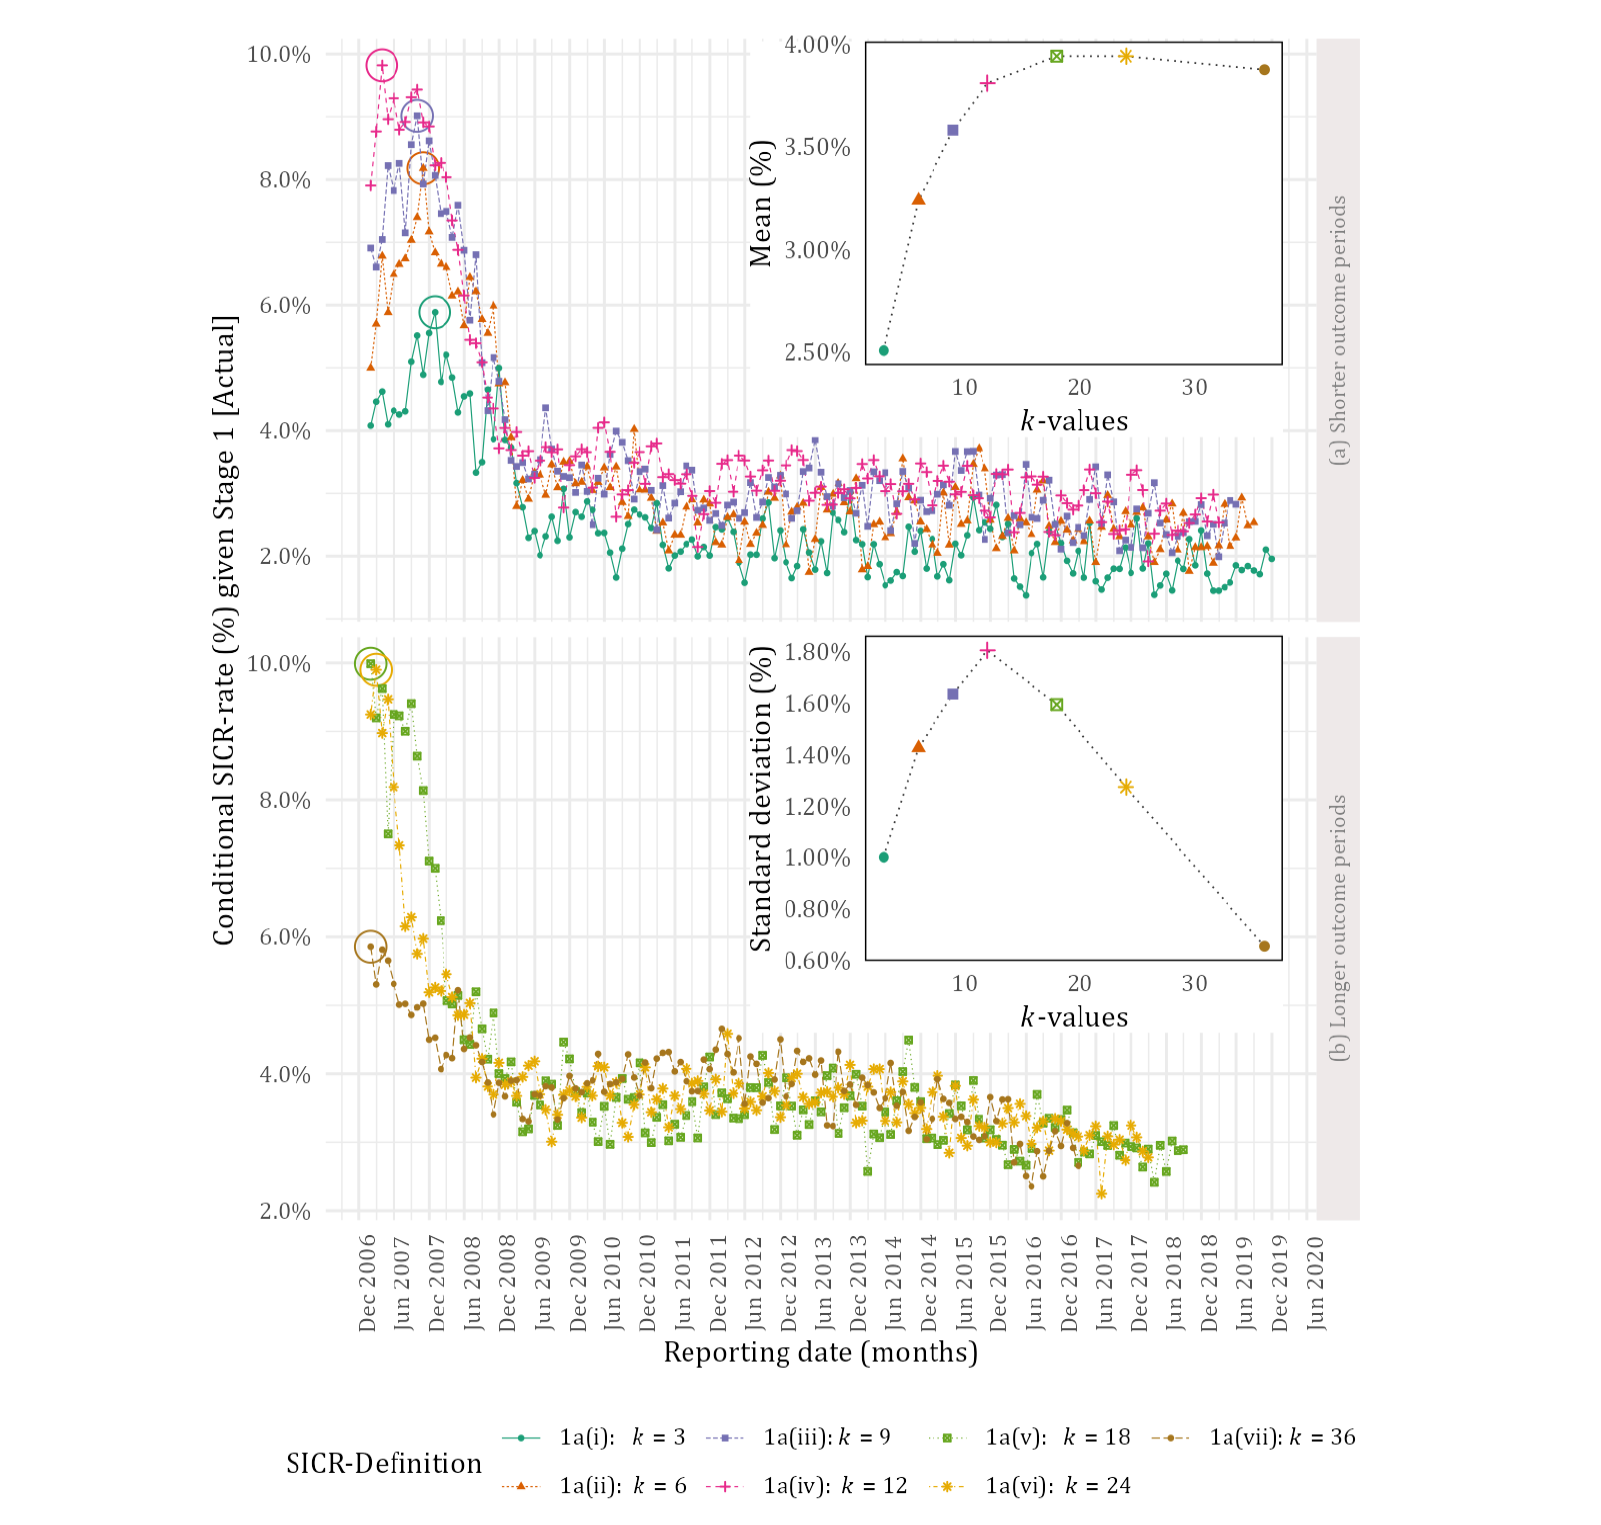

Each SICR-rate has a different but increasing mean-level as 𝑘 increases, especially when examined after the anomalous 2008 Global Financial Crisis (GFC). Since $𝑔_0(𝑡 + 𝑘) ≥ 3 > 𝑑$ will hold for both default and SICR-outcomes, larger 𝑘-values will increasingly capture a greater proportion of defaulting accounts, thereby explaining the phenomenon.

Moreover,teh figure reveals a plateauing effect in the mean, which suggests that choosing $𝑘 ≥ 18$ has a negligible contribution to the overall SICR-mean. At worst, choosing $𝑘 ≥ 18$ will increasingly select
default-instances into the sample, thereby ‘contaminating’ the SICR-mean. Doing so can detract from the very idea of SICR-staging, which should ideally act as a pro-cyclical early warning system for impending credit risk; see §B.5.5.21 in IFRS 9 from IASB (2014). The SICR-rate of each 𝑘-value also exhibits a unique volatility pattern, which is seemingly more stable at the extremes, i.e., $𝑘 ≤ 3$ and $𝑘 > 24$. However, stable SICR-rates may not necessarily be a useful pursuit, especially not during an unfolding macroeconomic crisis and its subsequent effect on default rates. In particular, the most stable SICR-rates also failed to track the increasing default rates during 2007-2008. 

As a working principle for defining the SICR-event, SICR-rates should reasonably exceed default rates since SICR-staging should ideally preempt default. This principle avails a useful heuristic in disqualifying both $𝑘 ≤ 3$ and $𝑘 > 24$, given their failure in tracking the 12-month default rate.

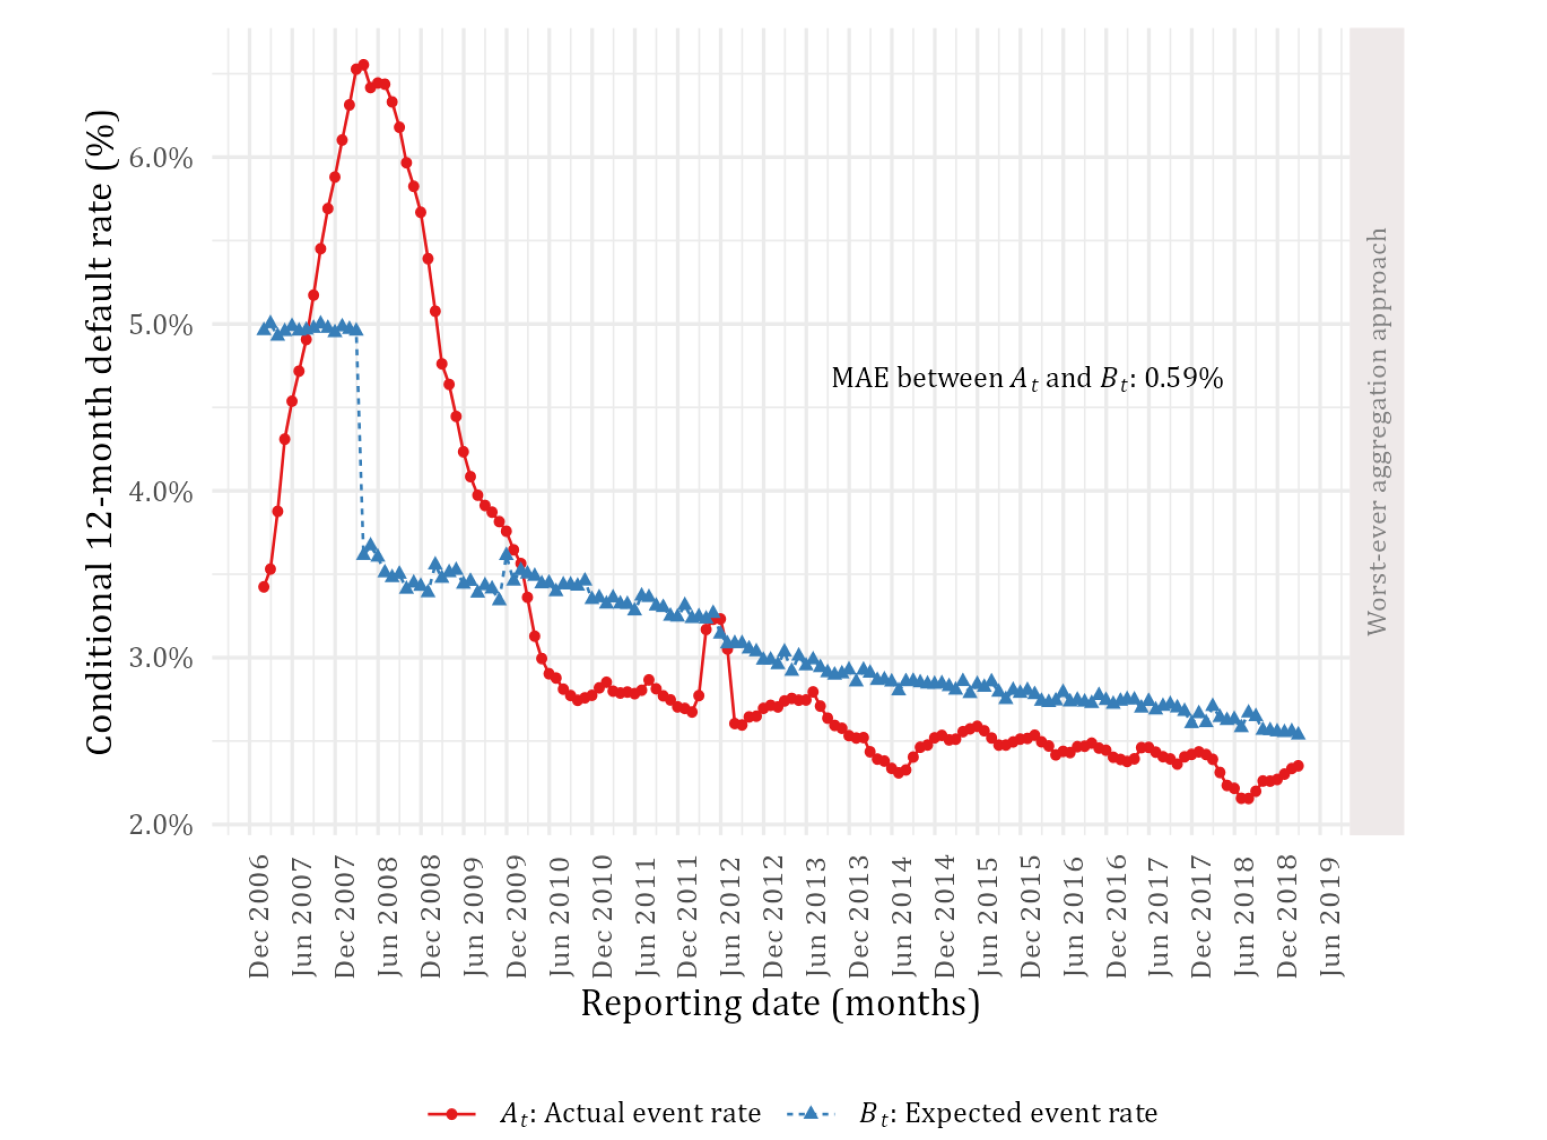

Consider then the portfolio-level 12-month conditional default probability, both time graphs should ideally overlap with each other quite closely, thereby suggesting that the aggregated predictions agree with reality. The early peak in $𝐴_𝑡$ clearly signifies the 2008-GFC, while $𝐵_𝑡$ reacts at least moderately in its prediction of the
prevailing default rates. Aside from the anomalous 2008-GFC, the prediction $𝐵_𝑡$ evidently exceeds the actual default experience $𝐴_𝑡$ across the majority of periods, which is reassuringly risk-prudent.

The actual SICR-rates per 𝑘-value can be further examined on the basis of various summary statistics, i.e., the earliest 𝑎(𝑘), the maximum 𝑏(𝑘), and the post-2008 mean 𝑐(𝑘). We define two elementary statistics as: 

1. The early warning degree 𝑏(𝑘) − 𝑎(𝑘), which denotes the degree to which a SICR-rate can respond to unfolding calamities
2. The recovery degree 𝑏(𝑘) − 𝑐(𝑘), which measures the magnitude by which the SICR-rate can normalise post-crisis.

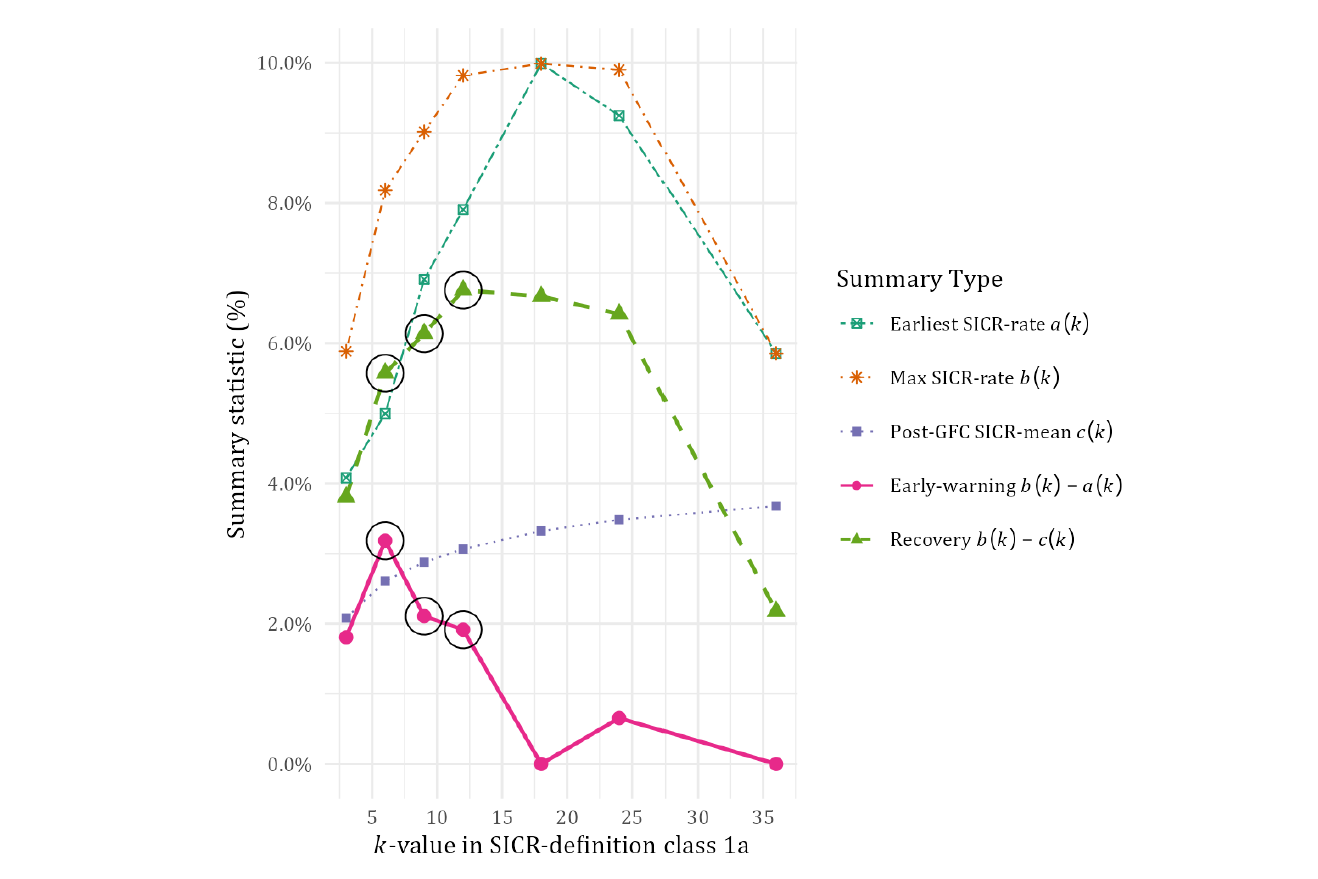

In the figure below, we show the time graphs of actual $𝐴_𝑡$ vs expected $𝐵_𝑡$ SICR-rates over calendar time 𝑡 for 𝑘 ∈ {3, 6, 9, 12}. Ideally, both time graphs should closely overlap each other, which would imply that our aggregated SICR-predictions agree with reality. One can measure the level of such agreement using the mean absolute error
(MAE) between $𝐴_𝑡$ and $𝐵_𝑡$.

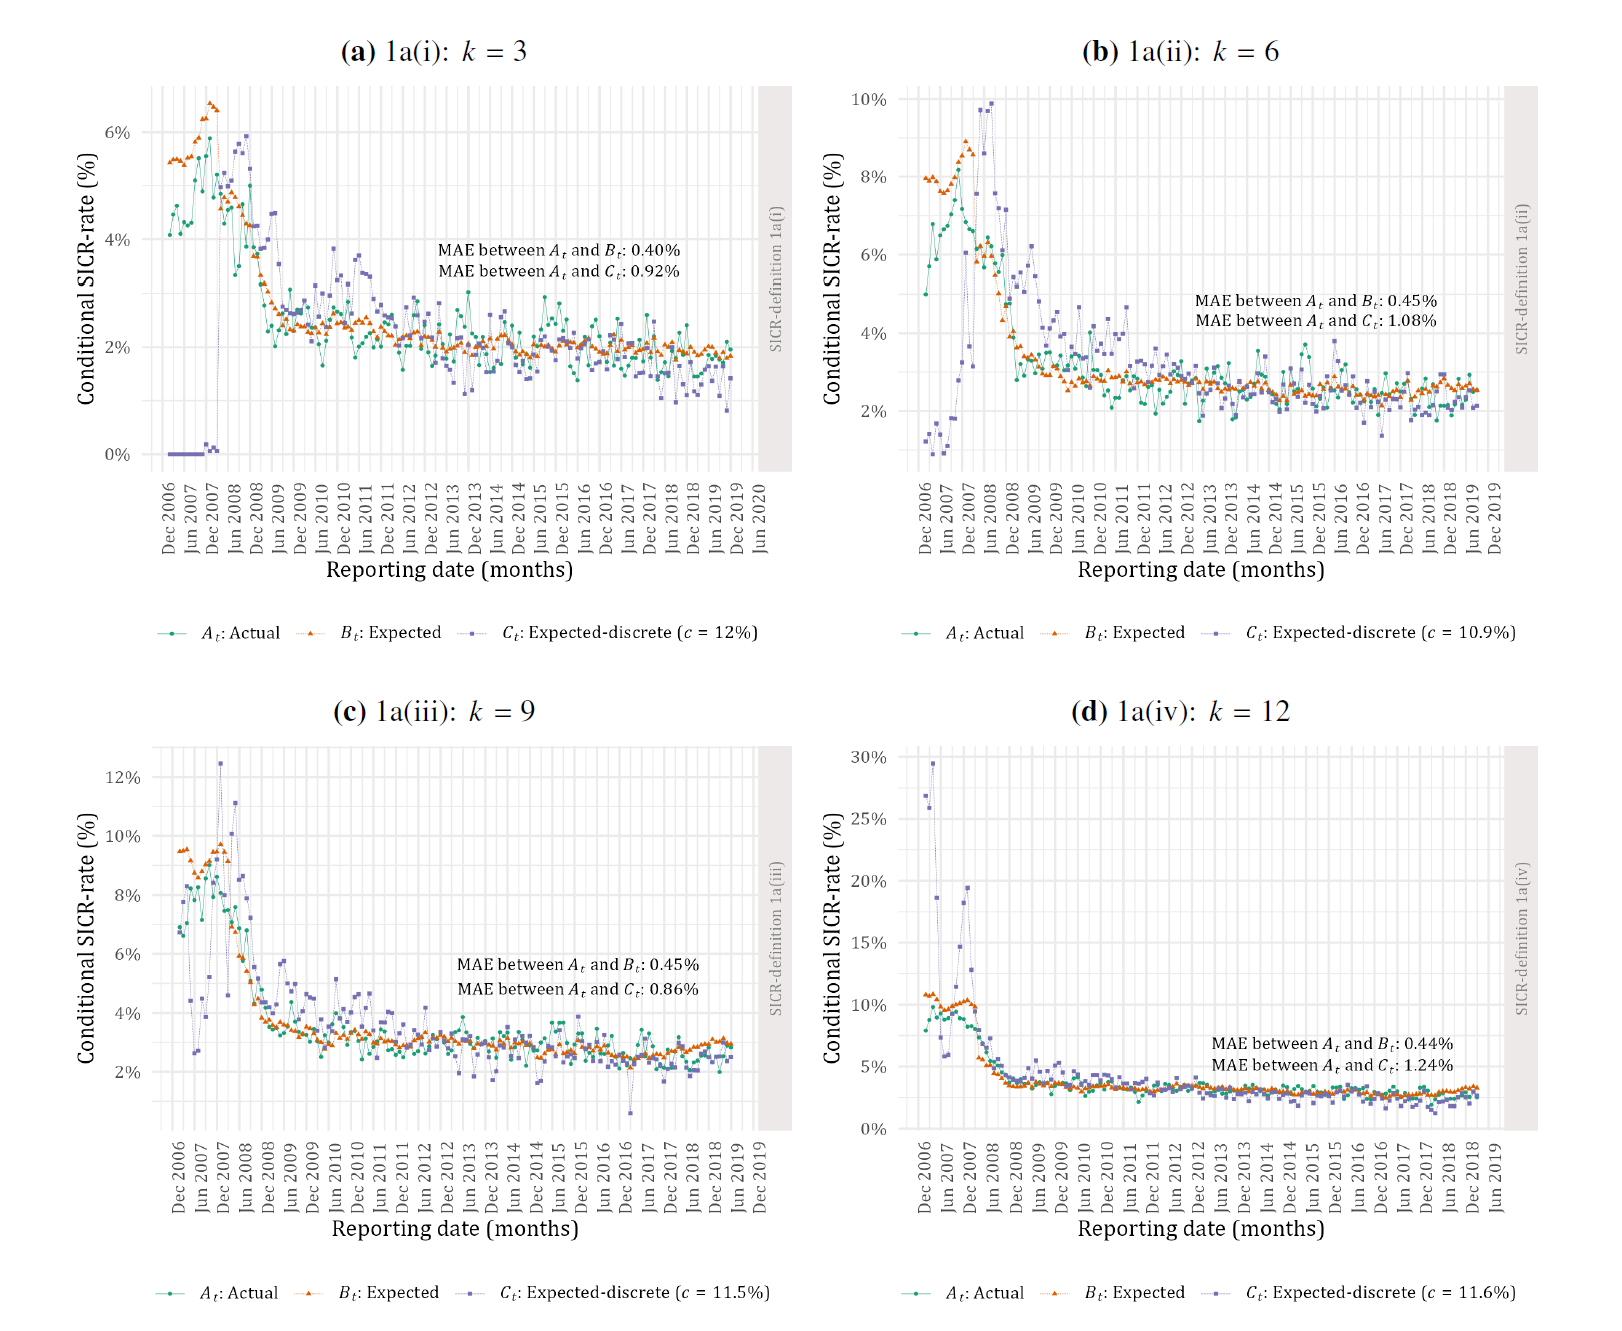

### **SICR Performance Metrics**

An important component of IFRS 9 modelling is the set of staging criteria. The evaluation of the staging criteria can be performed with quantitative indicators on stage transfers.

These types of metrics should be used to adequately assess the SICR criteria, including the calibration of quantitative SICR criteria.

- Proportion of transfers to stage 2 due to change in PD
- Proportion of transfers to stage 2 due solely to qualitative criteria
- Proportion of transfers to stage 2 due solely to backstop indicators
- Difference in PD for stage 2 and stage 1
- Stage 2 outflow to stage 1 (3-month average)
- Proportion of stage 3 that spent less than 12 months in stage 2
- Proportion of stage 3 that spent less than 6 months in stage 2
- Assessment of transition matrix among stages
- Comparison between transfer rate from stage 1 to 3 and from stage 2 to 3
- Proportion of stage 3 exposures moved directly from stage 1
- Comparison between default rates of stage 1 and Stage 2
- Average time in stage 2 before moving to stage 3


Some of these measures focus on SICR-predictions at the loan account-level (as summarised over time), while others are defined at the portfolio-level; both aggregation levels provide useful perspectives. These performance measures can also be applied more generally on the predictions and/or decisions of any binary SICR-classification system under IFRS 9. Doing so can foster comparability with our results, as well promote standardisation across the industry when evaluating or auditing SICR-decisions.

#### **Prevalance**

Assume a sample $D = \{𝑖, 𝑡, 𝑦_{𝑖𝑡}\}$ of binary-valued SICR-outcomes $𝑦_{𝑖𝑡}$ that are observed for accounts 𝑖 = 1, ... ,𝑁 at each period $𝑡 = 𝑡_1, . . . , 𝑇_𝑖 − 𝑘$ over each account’s lifetime $𝑇_𝑖$ from its time of initial recognition $𝑡_1$.

Given D of size $𝑛 = |D|$, we estimate the prevalence using Iverson brackets [·] as:

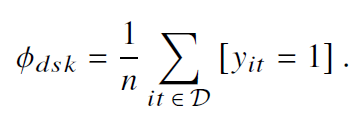

Put differently, 𝜙 is the proportion of rare events in D, which also measures the degree of class imbalance. Longer outcome periods also result in fewer observed SICR-outcomes, which explains the decreasing 𝜙-values, thereby signifying increased rarity.

#### **SICR-rates**

Denoted as $𝐴_𝑡$ , the SICR-rate estimates at reporting/calendar time 𝑡 the portfolio-level transition probability of moving from Stage 1 to Stage 2 impairment over a 𝑘-month period. More formally, $𝐴_𝑡$ estimates at 𝑡 the conditional probability $P(𝑌_{𝑡+𝑘} = 1| 𝑌_𝑡 = 0)$ of becoming SICR-flagged later at 𝑡 + 𝑘, where $𝑌𝑡 ,𝑌_{𝑡+1}, . . .$ are Bernoulli random variables that represent the SICR-status over 𝑡, as given by $G(𝑑, 𝑠, 𝑡)$.

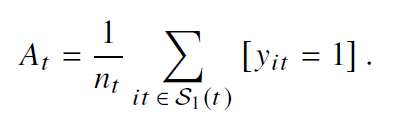

While the eqaution above yields the actual SICR-rate over time, the account-level predictions from an underlying SICR model can be similarly aggregated into an expected SICR-rate $B_𝑡$ , which can be duly compared to $𝐴_𝑡$ . This $B_𝑡$ -quantity similarly estimates at 𝑡 the conditional probability $P(𝑌_{𝑡+𝑘} = 1| 𝑌_𝑡 = 0, 𝑿)$ of becoming SICR-flagged later at 𝑡 + 𝑘, given the random input vector 𝑿. 

Estimating this probability implies developing a SICR-model from
data, which can then be used to render predictions on new data.

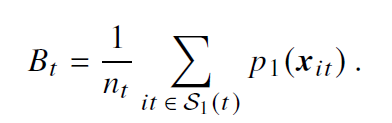

We formulate another variety of $B_t$ called the discretised expected SICR-rate $𝐶_𝑡$, wherein the underlying SICR-model (itself a discriminative/probabilistic classifier) is first dichotomised into a discrete classifier. This dichotomisation requires evaluating each SICR-prediction against a static cut-off 𝑐 ∈ [0, 1], thereby producing a
discrete SICR-prediction. 

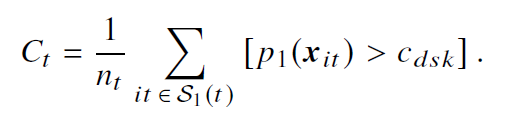

#### **Mean Rate**

This quantity is simply the sample mean of portfolio-level SICR-rates over time. Given the actual SICR-rates $𝐴_𝑡$ we estimate the SICR-mean over reporting time $𝑡 = 1, . . . , 𝑡_𝑛$ as:

$\bar A = \frac{1}{t_n} \sum_t A_t$

#### **Instability**

Denoted as 𝜎, the instability refers to the degree to which a series of portfolio-level SICR-rates varies over time.

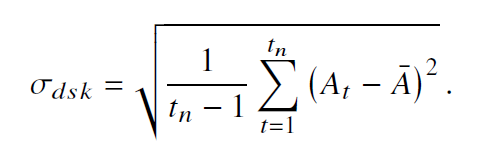

#### **Prediction Dynamicity**

Denoted as 𝜔, the dynamicity represents the extent to which the SICR-predictions (or probability scores) vary over the lifetime of an average loan account.

More formally, we first estimate each $𝜔_𝑖$ by calculating the account-level standard deviation of scores for each account 𝑖 in a given sample D, expressed as:

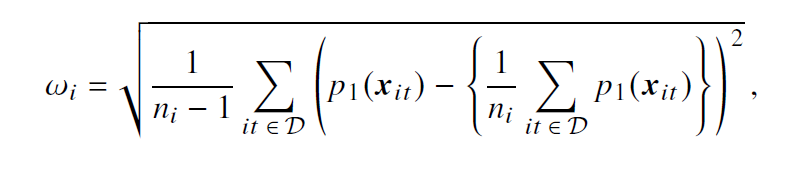

where $𝑛_𝑖 = 𝑇_𝑖 − 𝑘 > 0$ denotes the number of probability scores that are available for account 𝑖 in D. We finally estimate 𝜔 as:

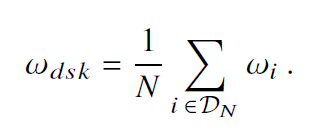

Smaller outcome periods clearly yield more accurate SICR-models that also produce more dynamic account level SICR-predictions. However, this dynamicity may not necessarily translate to the portfolio-level, especially since smaller 𝑘-values also produce more stable SICR-rates. At the account-level, extremely dynamic SICR-predictions (e.g., $𝑘 ≤ 3$) can lead to rapid oscillations in moving an account between Stages 1 and 2 over time. This oscillatory effect dampens the overall transition into Stage 2 when aggregating across accounts, hence the less responsive SICR-rate.

#### **AUC & ROC & Gini**

Secondly, the area under the curve (AUC) summarises a classical ROC-analysis (receiver operating characteristic) in measuring a model’s discriminatory power. 

AUC-values suggest that smaller outcome periods yield more accurate SICR-models than longer periods. This result corroborates the work of Kennedy et al. (2013) and Mushava and Murray (2018) wherein the outcome period was similarly varied in PD-modelling – an older ‘cousin’ of SICR-modelling. The plateauing effect in AUC-values suggest yet again that examining smaller 𝑘 ≤ 18 values is a more worthwhile endeavour.

This trend is mirrored in the discrete AUC-values, having dichotomised the SICR-predictions using 𝑐 as thresholds. Fewer SICR-outcomes can generally exacerbate the modelling task, which is why AUC decreases as 𝑘 increases.

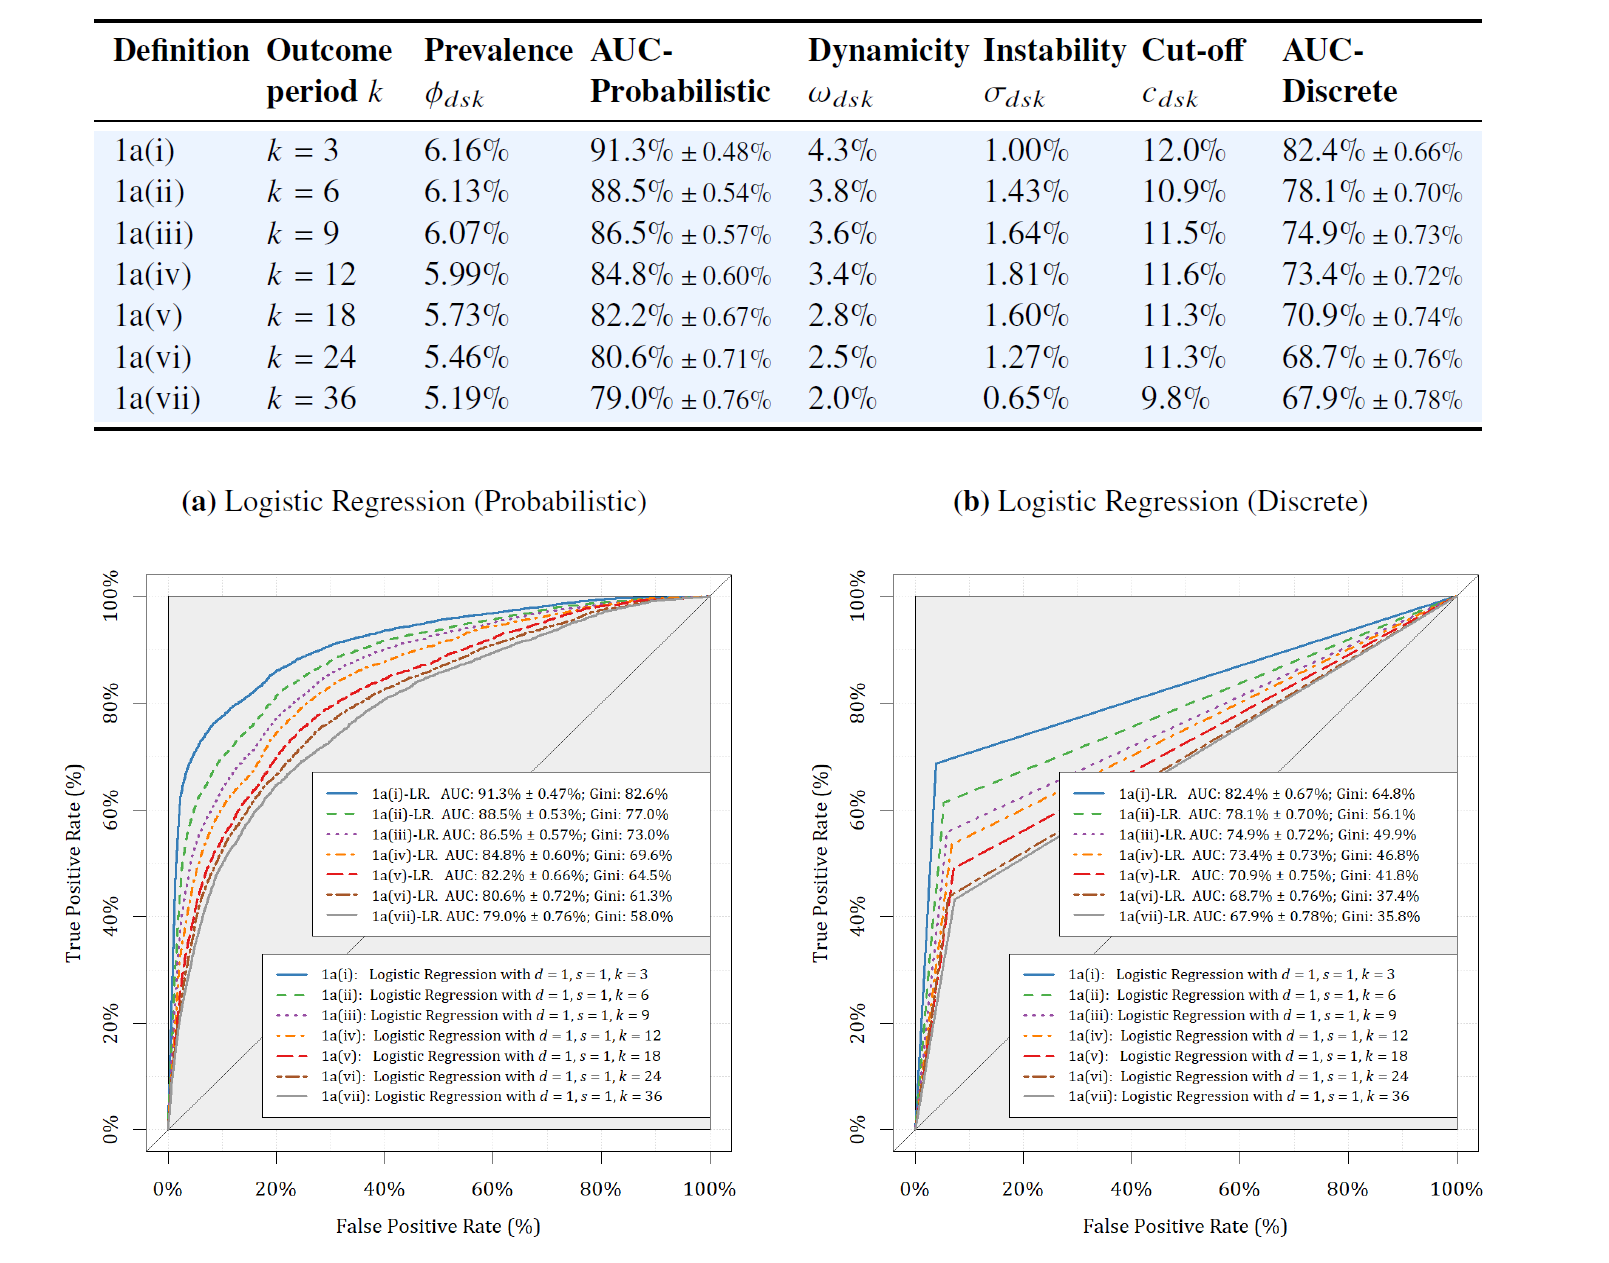

The midpoint 𝑘 = 9 therefore seems ‘optimal’ when considering the various trade-offs.

#### **MAE**

Most mean absolute error (MAE) between $𝐴_𝑡$ and $𝐵_𝑡$ ($𝑚_1$), are fairly similar with a mean error of 0.44% across 𝑘, barring 𝑘 ≥ 36. This result corroborates the relatively high AUC-values in the table above and visually suggests greater agreement as 𝑘 increases. Having dichotomised the SICR-models, a discretised expected SICR-rate ($C_𝑡$) emerges, which is similarly compared to 𝐴𝑡 and summarised again with the MAE ($𝑚_2$). Clearly, there is more disagreement between either rates, particularly during the 2008-GFC, with a mean $𝑚_2$-value of 1.11% across 𝑘; almost three times larger that of $𝑚_1$. Nonetheless, the smallest $𝑚_2$-value still occurred at 𝑘 = 9, which further supports its selection as the prudential choice.

### **Modelling vs Comparison** 🟢

Our SICR-modelling framework aims to provide a new and flexible way of conducting SICR-classification that is more proactive, focused, accurate, and dynamic than that of the classical PD-comparison approach. It is only natural then to compare the old to the new in identifying a superior approach. 

We therefore examine a few different choices of 𝑢 ∈ {100%, 120%, 150%, 180%, 200%, 300%} using discretion, though which deliberately includes the candidate 𝑢 = 200% from the European Banking Authority (2018), or EBA. Accordingly, the actual and discretised expected 1-month SICR-rates can be estimated respectively from the resulting sample of $𝑦_{𝑖𝑡}$ and $ℎ(𝒙_{𝑖𝑡})$ values. The prediction accuracy of the resulting SICR-classification is similarly gauged using ROC-analysis.

In summarising the ROC-analysis, the AUC-values clearly indicate that the prediction accuracy of $H$ is substantially inferior to that of any SICR-model, regardless of 𝑢.

Moreover, the AUC-values appear to be a monotonically decreasing function of 𝑢, where the AUC seems to deteriorate rapidly for 𝑢 ≥ 150%. The
EBA-recommended threshold of 𝑢 = 200% produced some of the most inaccurate SICR-predictions.

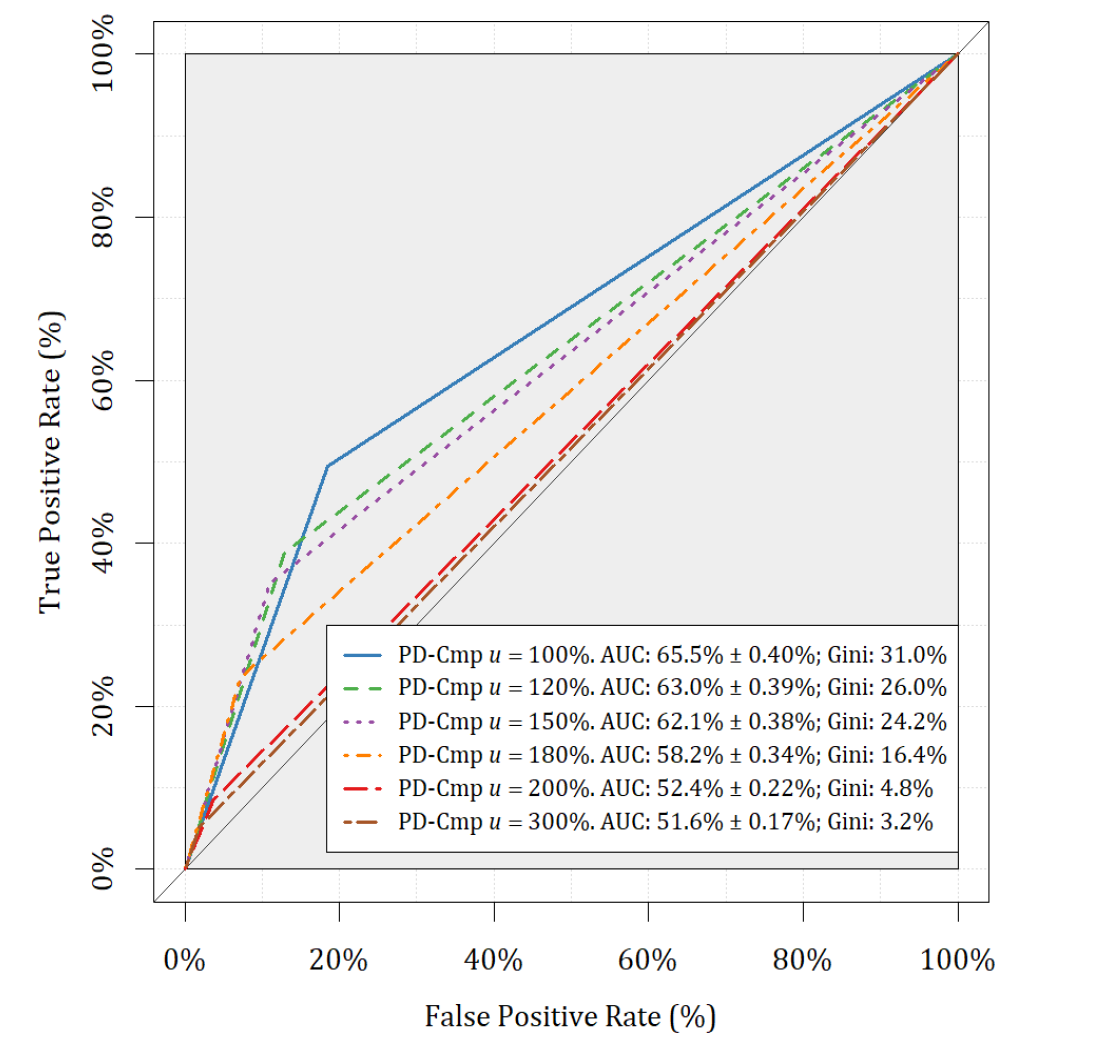

In comparing approaches, we select SICR-definition 1b(iii) and consider the resulting SICR model, which was previously motivated in subsection 4.3 as one of the best-performing SICR-models. Using the corresponding $𝑐_{129}$-value from Table 4 for this definition (𝑑 = 1, 𝑠 = 2, 𝑘 = 9), we dichotomise this SICR-model and similarly evaluate its discrete predictions within the validation set using ROC-analysis.

The resulting AUC-value of 76.8% indicates a decent level of accuracy, which compares favourably to that of the $H$-classifier. While its account-level prediction accuracy is clearly atrocious, the $H$-classifier may perform more admirably on the portfolio-level.

We therefore compare the time graphs of actual vs discretised expected SICR-rates, respective to both approaches and shown below. All of the expected rates across both approaches seemingly exceed their actual counterpart for most periods, which is certainly risk-prudent under IFRS 9. However, the degree of such over-prediction amounts to misallocated funds and wasted provisions, which can again be measured using the MAE
between two SICR-rates. The EBA-threshold (𝑢 = 200%) achieves a respectable MAE-value, which is reasonably close to that of the SICR-model, albeit still worse. More importantly, the MAE-value of the EBA-threshold is more than 7 times lower than that of the best-AUC threshold (𝑢 = 100%). Despite its improved prediction accuracy at the
account-level, the best-AUC threshold clearly results in an overly conservative SICR-rate at the portfolio-level, which surely poses an immense opportunity cost.

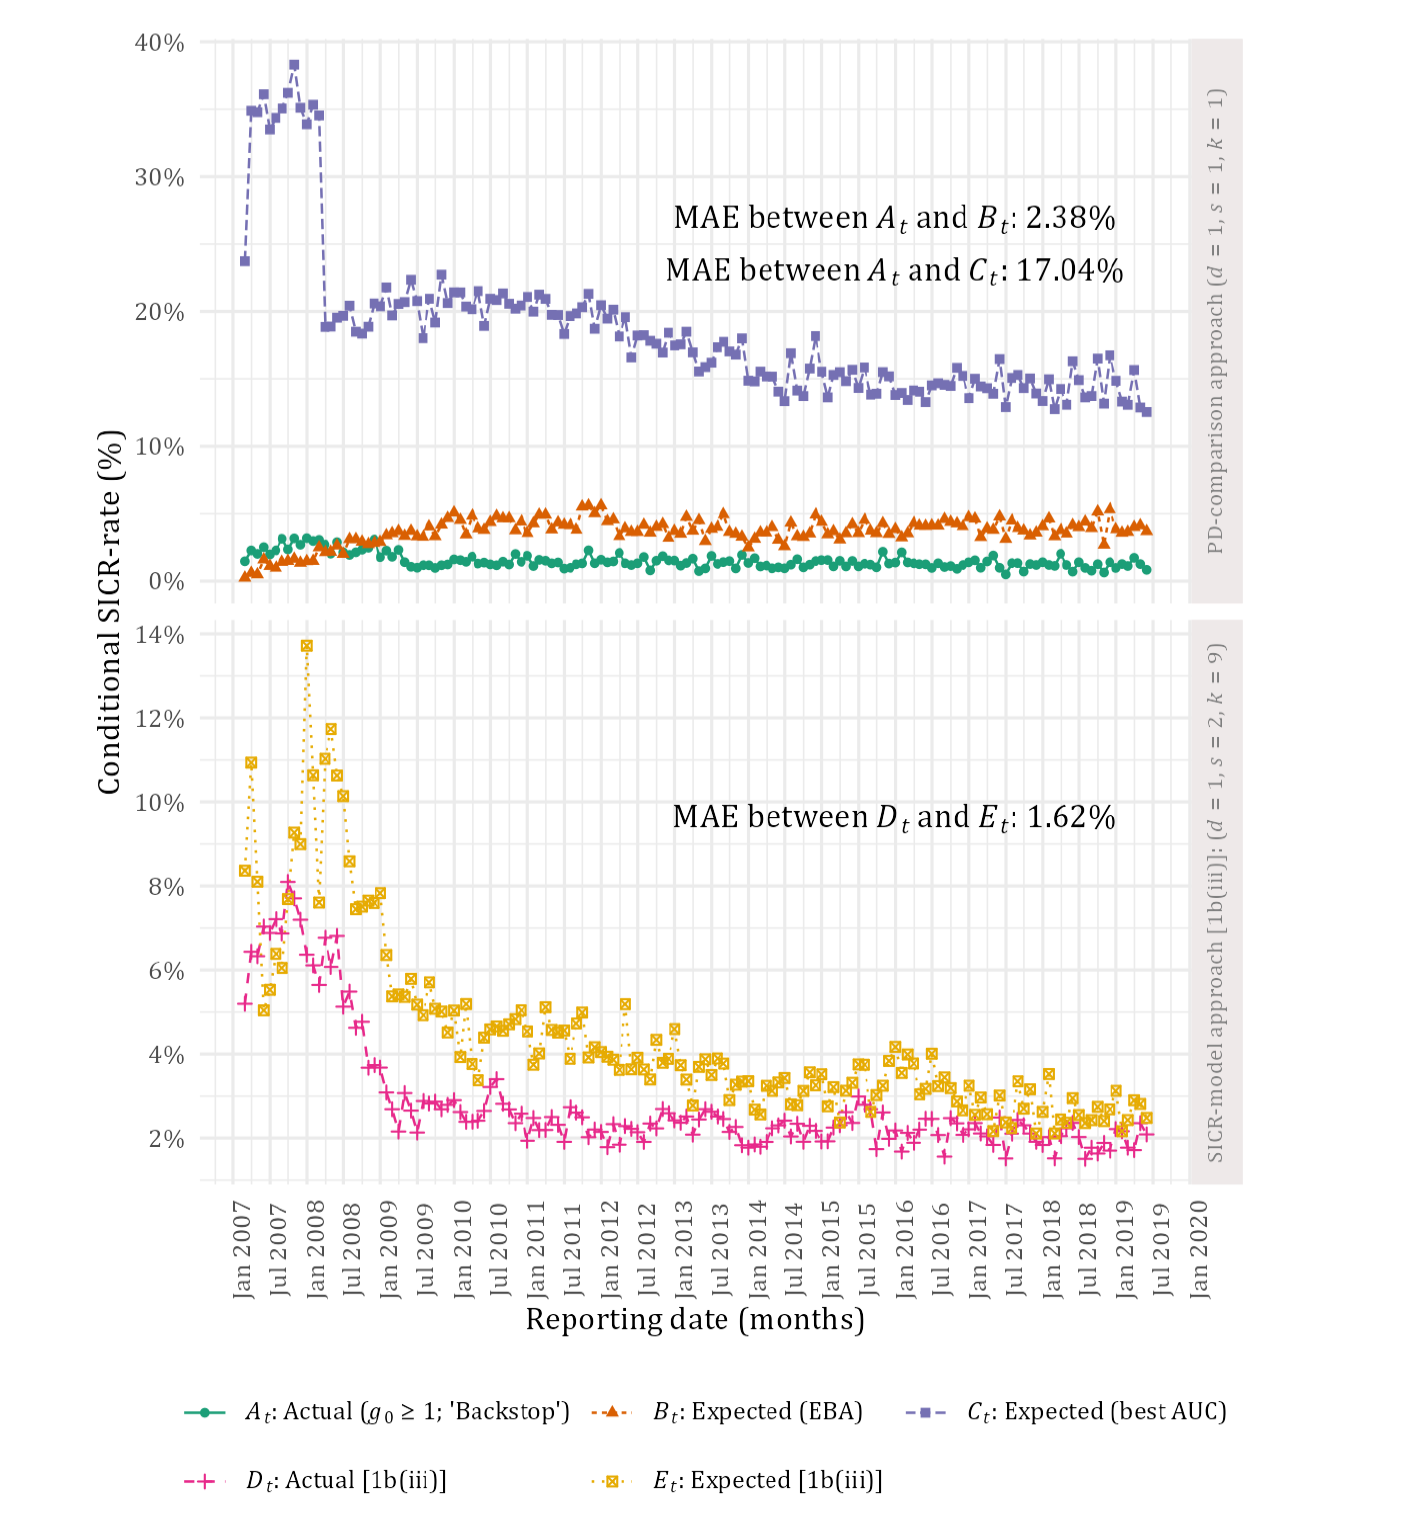

It also demonstrates different volatility patterns in the underlying SICR-rates across both approaches. In particular, the actual SICR-rate (in green) from the PD-comparison approach reacted rather mildly to the onset of the 2008-GFC, relative to its counterpart (in pink) from the SICR-modelling approach. We largely ascribe this result to the former’s use of 𝑘 = 1, which usually causes volatility in PD-modelling due to risk immaturity in the outcomes;

On the other hand, the two expected SICR-rates from the PD-comparison approach either under-predict their actual counterpart during the 2008-GFC (shown in orange: EBA-threshold), or massively over-predict it (shown in purple: best-AUC threshold). Both of these results are unsatisfactory and highlight the main drawbacks of the PD-comparison approach: 1) its tacit reliance on an appropriately accurate PD-model; and 2) its extraordinary sensitivity to the 𝑢-threshold. In contrast, both rates (in yellow and pink) from the SICR-modelling approach react more flexibly and intuitively as the 2008-GFC unfolds, having achieved a more pronounced peak at the height of the crisis without becoming excessive. Although decent, the dichotomisation of the SICR-model can surely be improved in future studies by tweaking the $𝑐_{129}$-threshold,
which should result in even better performance. However, and in finalising the approach comparison, the evidence suggests that the SICR-modelling approach is objectively the superior approach.

Our approach is more parsimonious than PD-comparisons since
the inputs of a SICR-model can relate more directly to the change in delinquency risk, instead of just default risk alone. As one of these inputs, the PD-ratio already signifies the change in risk since initial recognition, thereby rendering the predictions from a SICR-model as compliant with §5.5.9 of IFRS 9. Moreover, a SICR-modelling approach allows drawing statistical inference on the drivers of the overall SICR-process as a stochastic phenomenon, which can certainly help in portfolio management. Lastly, our approach prevents any pre-existing issues within a PD-model from bleeding into staged impairment classification under IFRS 9, which can be another practical benefit.

The 𝑠-parameter has a stabilising yet costly effect on SICR-classification, wherein SICR-events become scarcer as 𝑠 increases. Greater stickiness yield account-level SICR-predictions that are more accurate but also less dynamic over loan life. From these stickier SICR-definitions, the resulting portfolio-level SICR-rates become
less dynamic over time, have lower means, and are increasingly insensitive to the 2008-GFC. Furthermore, both 𝑘 and 𝑠 parameters interact with each other in that SICR-predictions become more accurate as 𝑘 decreases and 𝑠 increases. However, the dynamicity of account-level predictions decreases for larger 𝑠 but increases again for smaller 𝑘. Lastly, choosing 𝑑 = 2 yields extremely scarce SICR-events across all values of 𝑠 and 𝑘, which would compromise the resulting Stage 2 provision-levels if used; a result that supports the ‘backstop’ (𝑑 = 1) of IFRS 9. These trends form a reusable analytical framework in which any SICR-definition can be examined on the following four factors: the accuracy and dynamicity of the resulting SICR-predictions, the instability of implied SICR-rates, and its responsiveness to economic distress. A reasonable trade-off exists amongst these factors when choosing 𝑘 = 9 across any 𝑠-value, as well as when selecting 𝑠 = 2 across 𝑘 ∈ {6, 9}.